# Introduction

**Definition:**  
    ACO is a **probabilistic**, **meta-heuristic** optimization technique inspired by the foraging behavior of real ants.  
    It is used to solve computational problems that involve finding optimal paths **through direct graphs**.

**Core Idea:**  
    Artificial "ants" (computational agents) mimic the **pheromone-based** communication of real ants to locate optimal solutions in a search space.

**Inspiration:**  
    Real ants deposit pheromones on paths to food sources, and other ants follow **stronger pheromone** trails, leading to collective discovery of **shorter paths**.

**Applications:**  
    Widely used for graph-based optimization problems, such as vehicle routing, internet routing, and scheduling.

# Algorithm Structure

## Problem Representation:

The optimization problem is modeled as a **weighted graph**, where the 

Modeled as a weighted graph $G=(V,E)$:  
Where:
- $V$: Nodes
- $E$: Edges with weights

Goal is to find the **shortest path** in the graph.

## Steps in ACO:

- **Initialization:**

    Place $m$ ants on random nodes.  
    Initialize pheromone trails $\tau_{ij}$ (e.g., $\tau_{0}/avg-path-length$).

- **Solution Construction:**
    - Each ant constructs a solution by probabilistically choosing edges based on:
        - **Pheromone level** ($\tau_{ij}$): Indicates how desirable a path is based on past solutions.
        - **Heuristic information** ($\eta_{ij}$): Represents a priori desirability (e.g., inverse of edge distance, $1/d_{xy}$).

- **Edge Selection Probability:**
    $$p_{ij}^{k} = \frac{(\tau_{ij}^{\alpha})(\eta_{ij}^{\beta})}{\sum_{z \in {N_j}^k} (\tau_{iz}^{\alpha})(\eta_{iz}^{\beta})}$$
    Where:
    - $\tau_{ij}$: Pheromone on edge ($i,j$)
    - $\eta_{ij}$: Heuristic value (e.g., $1/d_{ij}$  for TSP).
    - $\alpha$: Controls pheromone influence (how much ants rely on past solutions).
    - $\beta$: Controls heuristic influence (how much ants prefer shorter distances).
    - ${N_j}^k$: Nodes accessible from $i$ and unvisited by ant $k$

- **Pheromone Update:**
    - After all ants complete their paths, pheromone levels are updated:
        $$\tau_{ij} \leftarrow \underbrace{(1-\rho)\tau_{ij}}_{\text{Evaporation}} + \sum_{k}^{m} \underbrace{\Delta \tau_{ij}^{k}}_{\text{Deposit}}$$
        Where:
        - $\rho$: Pheromone evaporation coefficient (reduces pheromone over time).
        - $\Delta \tau_{ij}^{k}$: Pheromone deposited by ant $k$, proportional to solution quality (e.g., $Q/L_k$, where $L_k$ is the tour length):
            $$
            \Delta \tau_{ij}^{k} = \begin{cases}
                \frac{Q}{L_k} & \text{if ant $k$ uses curve $ij$ in its tour} \\
                0 & \text{otherwise}
            \end{cases}
            $$

- **Termination:**
    - Repeat until convergence (e.g., max iterations or no improvement).

# Pseudocode

> procedure ACO_MetaHeuristic  
> &emsp;&emsp;while termination condition not met do  
> &emsp;&emsp;&emsp;&emsp;generateSolutions()  
> &emsp;&emsp;&emsp;&emsp;daemonActions()  
> &emsp;&emsp;&emsp;&emsp;pheromoneUpdate()  
> &emsp;&emsp;end  

## Key Parameters and Their Effects:

1. **Number of Ants (m):**
   - **Too few:** May not explore enough of the search space
   - **Too many:** Computational overhead without significant improvement
   - **Recommended:** 10-50 ants for most problems

2. **Pheromone Importance (α):**
   - **Low values (0-1):** Less reliance on pheromone trails, more exploration
   - **High values (2-5):** Stronger exploitation of good paths
   - **Recommended:** 1-2 for balanced exploration/exploitation

3. **Heuristic Importance (β):**
   - **Low values (0-1):** Less preference for shorter distances
   - **High values (2-5):** Strong preference for shorter distances
   - **Recommended:** 2-5 for distance-based problems

4. **Evaporation Rate (ρ):**
   - **Low values (0.01-0.1):** Slow convergence, more exploration
   - **High values (0.3-0.5):** Fast convergence, may get stuck in local optima
   - **Recommended:** 0.1-0.3

5. **Number of Iterations:**
   - Depends on problem size and complexity
   - **Small problems:** 50-100 iterations
   - **Large problems:** 200-1000 iterations

# Codes

## Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Ant Colony Optimization

In [5]:
class AntColonyOptimization:
    def __init__(self, n_ants=50, n_iterations=100, decay=0.1, alpha=1, beta=2):
        """
        Initialize ACO parameters
        
        Parameters:
        - n_ants: Number of ants
        - n_iterations: Number of iterations
        - decay: Pheromone decay rate
        - alpha: Pheromone importance factor
        - beta: Heuristic importance factor
        """
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.decay = decay
        self.alpha = alpha
        self.beta = beta
        
    def solve_tsp(self, distances):
        """
        Solve Traveling Salesman Problem using ACO
        
        Parameters:
        - distances: Distance matrix between cities
        
        Returns:
        - best_path: Best tour found
        - best_distance: Length of best tour
        - history: List of best distances per iteration
        """
        n_cities = len(distances)
        
        # Initialize pheromone matrix
        pheromone = np.ones((n_cities, n_cities)) / n_cities
        
        # Calculate heuristic information (inverse of distance)
        heuristic = 1 / (distances + np.eye(n_cities))
        
        best_path = None
        best_distance = float('inf')
        history = []
        
        for iteration in range(self.n_iterations):
            # Generate solutions for all ants
            all_paths = self._generate_solutions(distances, pheromone, heuristic)
            
            # Calculate distances for all paths
            all_distances = [self._calculate_distance(path, distances) for path in all_paths]
            
            # Update best solution
            min_distance_idx = np.argmin(all_distances)
            if all_distances[min_distance_idx] < best_distance:
                best_distance = all_distances[min_distance_idx]
                best_path = all_paths[min_distance_idx]
            
            # Update pheromone
            pheromone = self._update_pheromone(pheromone, all_paths, all_distances)
            
            history.append(best_distance)
            
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best distance = {best_distance:.2f}")
        
        return best_path, best_distance, history
    
    def _generate_solutions(self, distances, pheromone, heuristic):
        """Generate solutions for all ants"""
        n_cities = len(distances)
        all_paths = []
        
        for ant in range(self.n_ants):
            # Start from random city
            current_city = random.randint(0, n_cities - 1)
            unvisited = list(range(n_cities))
            unvisited.remove(current_city)
            path = [current_city]
            
            # Build path
            while unvisited:
                # Calculate probabilities for next city
                probabilities = self._calculate_probabilities(
                    current_city, unvisited, pheromone, heuristic
                )
                
                # Choose next city based on probabilities
                next_city = random.choices(unvisited, weights=probabilities)[0]
                path.append(next_city)
                unvisited.remove(next_city)
                current_city = next_city
            
            all_paths.append(path)
        
        return all_paths
    
    def _calculate_probabilities(self, current_city, unvisited, pheromone, heuristic):
        """Calculate probabilities for choosing next city"""
        probabilities = []
        
        for city in unvisited:
            # Pheromone and heuristic values
            tau = pheromone[current_city][city]
            eta = heuristic[current_city][city]
            
            # Calculate probability
            prob = (tau ** self.alpha) * (eta ** self.beta)
            probabilities.append(prob)
        
        # Normalize probabilities
        total = sum(probabilities)
        if total == 0:
            # If all probabilities are zero, use uniform distribution
            probabilities = [1] * len(probabilities)
            total = len(probabilities)
        
        return [p / total for p in probabilities]
    
    def _calculate_distance(self, path, distances):
        """Calculate total distance of a path"""
        total_distance = 0
        for i in range(len(path)):
            from_city = path[i]
            to_city = path[(i + 1) % len(path)]
            total_distance += distances[from_city][to_city]
        return total_distance
    
    def _update_pheromone(self, pheromone, all_paths, all_distances):
        """Update pheromone levels"""
        n_cities = len(pheromone)
        
        # Evaporate pheromone
        pheromone = (1 - self.decay) * pheromone
        
        # Add new pheromone
        for path, distance in zip(all_paths, all_distances):
            for i in range(len(path)):
                from_city = path[i]
                to_city = path[(i + 1) % len(path)]
                # Add pheromone inversely proportional to distance
                pheromone[from_city][to_city] += 1.0 / distance
                pheromone[to_city][from_city] += 1.0 / distance  # Symmetric
        
        return pheromone

## Example Usage

In [6]:
# Example usage
def create_random_cities(n_cities=10, seed=42):
    """Create random city coordinates and distance matrix"""
    np.random.seed(seed)
    cities = np.random.rand(n_cities, 2) * 100
    
    # Calculate distance matrix
    distances = np.zeros((n_cities, n_cities))
    for i in range(n_cities):
        for j in range(n_cities):
            distances[i][j] = np.sqrt(np.sum((cities[i] - cities[j])**2))
    
    return cities, distances

# Run ACO on TSP
cities, distances = create_random_cities(n_cities=10)
aco = AntColonyOptimization(n_ants=20, n_iterations=50, decay=0.1, alpha=1, beta=2)
best_path, best_distance, history = aco.solve_tsp(distances)

print(f"\nBest path found: {best_path}")
print(f"Best distance: {best_distance:.2f}")

Iteration 0: Best distance = 316.98
Iteration 10: Best distance = 290.31
Iteration 20: Best distance = 290.31
Iteration 30: Best distance = 290.31
Iteration 40: Best distance = 290.31

Best path found: [4, 1, 6, 9, 7, 2, 8, 3, 5, 0]
Best distance: 290.31


## Visualization

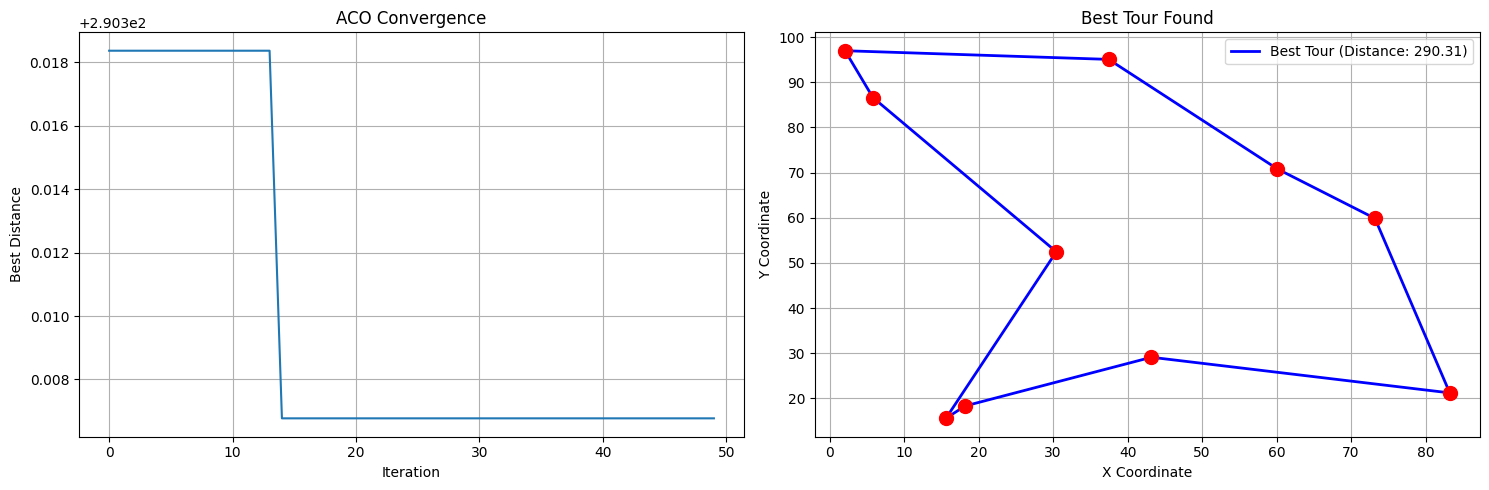

In [4]:
# Plot results
plt.figure(figsize=(15, 5))

# Plot convergence
plt.subplot(1, 2, 1)
plt.plot(history)
plt.title('ACO Convergence')
plt.xlabel('Iteration')
plt.ylabel('Best Distance')
plt.grid(True)

# Plot best tour
plt.subplot(1, 2, 2)
best_path_closed = best_path + [best_path[0]]  # Close the tour
tour_x = [cities[i][0] for i in best_path_closed]
tour_y = [cities[i][1] for i in best_path_closed]

plt.plot(tour_x, tour_y, 'b-', linewidth=2, label=f'Best Tour (Distance: {best_distance:.2f})')
plt.scatter(cities[:, 0], cities[:, 1], c='red', s=100, zorder=5)
plt.title('Best Tour Found')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# References

[Wikipedia - Ant colony optimization algorithms](https://en.wikipedia.org/wiki/Ant_colony_optimization_algorithms)

[Simulife Hub - Ant colony optimization algorithm](https://youtu.be/u7bQomllcJw?si=vtTFKNFeM1aBtwwp)

Dorigo, M., Maniezzo, V., & Colorni, A. (1996). Ant system: optimization by a colony of cooperating agents. IEEE Transactions on Systems, Man, and Cybernetics, Part B, 26(1), 29-41.